In [33]:
# import helper functions 
from extract_simple import *
from simpleGNN import *

import torch
import torch.nn as nn
import torch.optim as optim 
import matplotlib.pyplot as plt
import seaborn as sns

# from torch import nn
from torch_geometric.nn import GCNConv, global_mean_pool, Sequential, AttentionalAggregation
from torch_geometric.loader import DataLoader
from tqdm import tqdm

## Section 0: Setting Up

Below, helper functions are defined for model training, validation, and testing. A helper function for plotting has also been defined, to help visualize the loss curves. 

In [4]:
def train_model(model, train_loader, val_loader, loss_fn, optimizer,        # code taken from Module 9 bloodmnist_pytroch.ipynb demo 
                epochs=10, print_every=1, device='cpu'):

    # for keeping track of total loss
    history = {'train_loss': [], 'val_loss': [],
               'train_mae': [], 'val_mae': [],
               'train_rmse': [], 'val_rmse': []}


    model = model.to(device) # move to device (cpu/gpu/mps as specified)

    for epoch in tqdm(range(epochs), desc='Training'):
        # TRAINING
        model.train()
        
        # initialize losses to 0 at start of each epoch 
        epoch_train_loss = 0.0
        epoch_train_mae = 0.0
        epoch_train_rmse = 0.0
        train_n = 0

        # iterate thru each batch 
        for batch in train_loader:
            batch = batch.to(device) # move to specified device 

            # inputs [x, edge_index, batch]
            predictions = model(batch.x, batch.edge_index, batch.batch)
            targets = batch.y.reshape(-1).float() # reshape 

            # compare to target and calculate loss 
            loss = loss_fn(predictions, targets)

            optimizer.zero_grad() # zero out grads
            loss.backward() # back-prop 
            optimizer.step() # update/adjust 

            # calculate losses 
            epoch_train_loss += loss.item() # from optimizer 
            epoch_train_mae += torch.abs(predictions - targets).sum().item()
            epoch_train_rmse += ((predictions - targets) ** 2).sum().item()
            train_n += targets.numel()

        # calculate avg loss
        avg_train_loss = epoch_train_loss / len(train_loader)
        avg_train_mae = epoch_train_mae / train_n
        avg_train_rmse = (epoch_train_rmse / train_n) ** 0.5

        # Validation
        model.eval()
        epoch_val_loss = 0.0
        epoch_val_mae = 0.0
        epoch_val_rmse = 0.0
        val_n = 0

        with torch.no_grad():
            for val_batch in val_loader:
                val_batch = val_batch.to(device)

                val_predictions = model(val_batch.x, val_batch.edge_index, val_batch.batch).reshape(-1)
                val_targets = val_batch.y.reshape(-1).float()

                val_loss = loss_fn(val_predictions, val_targets)

                epoch_val_loss += val_loss.item()

                epoch_val_mae += torch.abs(val_predictions - val_targets).sum().item()
                epoch_val_rmse += ((val_predictions - val_targets) ** 2).sum().item()
                val_n += val_targets.numel()

        avg_val_loss = epoch_val_loss / len(val_loader)
        avg_val_mae = epoch_val_mae / val_n
        avg_val_rmse = (epoch_val_rmse / val_n) ** 0.5


        # Record
        history['train_loss'].append(avg_train_loss)
        history['train_mae'].append(avg_train_mae)
        history['train_rmse'].append(avg_train_rmse)

        history['val_loss'].append(avg_val_loss)
        history['val_mae'].append(avg_val_mae)
        history['val_rmse'].append(avg_val_rmse)
        
        if (epoch + 1) % print_every == 0:
            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"Train Loss: {avg_train_loss:.4f} | "
                f"Val Loss: {avg_val_loss:.4f}"
            )

    return history

In [20]:
def test_model(model, test_loader, loss_fn, device='cpu'):
    history = {'test_loss': [], 'test_mae': [], 'test_rmse': []}

    model = model.to(device)
    model.eval()

    total_loss = 0.0
    total_mae = 0.0
    total_mse = 0.0
    n = 0

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)

            predictions = model(batch.x, batch.edge_index, batch.batch).reshape(-1)
            targets = batch.y.reshape(-1).float() # reshape 

            loss = loss_fn(predictions, targets)

            total_loss += loss.item()
            total_mae += torch.abs(predictions - targets).sum().item()
            total_mse += ((predictions - targets) ** 2).sum().item()
            n += targets.numel()

    avg_loss = total_loss / len(test_loader)
    avg_mae = total_mae / n
    avg_rmse = (total_mse / n) ** 0.5

    history['test_loss'].append(avg_loss)
    history['test_mae'].append(avg_mae)
    history['test_rmse'].append(avg_rmse)

    print(
        f"Test Loss: {avg_loss:.4f} | "
        f"Test MAE: {avg_mae:.4f} | "
        f"Test RMSE: {avg_rmse:.4f}"
    )

    return history

In [5]:
def plot_train_val(history, model_name):
    """Plot training vs validation loss from a history dict."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].plot(history['train_mae'], label='Train', linewidth=2)
    ax[0].plot(history['val_mae'], label='Validation',
             linewidth=2, linestyle='--')
    ax[0].set_title(f'MAE')
    # ax[0].set_xlim(4)
    ax[0].grid(alpha=0.3)
    ax[0].legend()

    ax[1].plot(history['train_rmse'], label='Train', linewidth=2)
    ax[1].plot(history['val_rmse'], label='Validation',
             linewidth=2, linestyle='--')
    ax[1].set_title(f'RMSE')
    ax[1].grid(alpha=0.3)
    ax[1].legend()

    fig.suptitle(f"MAE and RMSE for {model_name}")

    plt.tight_layout()
    plt.show()

## Section 1: Loading the Dataset

In [7]:
my_path = '../../data'

# --------- EDIT THIS VALUE TO CHANGE EFFECTIVE DATASET SIZE -------------
max_mols = 20000

files_list = find_files(my_path)

# Process files from list and extract specified number of molecules and type
dataset = process_file(files_list, molecule_type = 'biomolecules', max_molecules = max_mols)

# Get final dataset for use with PyG 
torch_data = get_data(dataset)

train_dataset, val_dataset, test_dataset = split_data(torch_data, 0.2, 0.2)
# train_dataset, val_dataset = split_data(torch_data, 0.2)

# print(len(train_dataset), len(val_dataset), len(test_dataset))
print(len(train_dataset), len(val_dataset), len(test_dataset))

Processed 20000 atoms
12800 3200 4000


In [8]:
# set batch size 
BATCH_SIZE = 32

# loaders 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

## Section 2: Simple GNNs

### Section 2.1: SimpleGNN 

SimpleGNN is our simplest, most traditional GNN. In addition to serving as our performance baseline, we used simpleGNN to help us learn about this neural network architecture, as we had not yet covered this topic in class. 

SimpleGNN consists of 3 convolutional layers, and a final MLP layer. It uses global mean pooling. The goal of this baseline model is to be "vanilla". 

In [9]:
class SimpleGNN(nn.Module):
    def __init__(self, num_node_features=1, hidden_channels=128):
        # call constructor from parent class 
        super().__init__()

        self.simpleGNN = Sequential('x, edge_index, batch', [
            # CONVOLUTION LAYERS: learn molecular represenation 
            # layer 1: directly bonded atoms
            (GCNConv(num_node_features, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),
            # layer 2: local chemical environment (i.e., funct groups)
            (GCNConv(hidden_channels, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),
            # layer 3: adds global context
            (GCNConv(hidden_channels, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),

            # POOLING: down-sample/reduce dimensions 
            (global_mean_pool, 'x, batch -> x'),

            # LINEAR LAYERS: turn into actual predictions 
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1)])


    def forward(self, x, edge_index, batch):
        return self.simpleGNN(x, edge_index, batch).reshape(-1)

Training:  20%|██        | 10/50 [02:08<08:38, 12.96s/it]

Epoch  10/50 | Train Loss: 0.8537 | Val Loss: 0.8413


Training:  40%|████      | 20/50 [04:20<06:30, 13.03s/it]

Epoch  20/50 | Train Loss: 0.8497 | Val Loss: 0.8545


Training:  60%|██████    | 30/50 [06:24<04:09, 12.50s/it]

Epoch  30/50 | Train Loss: 0.8475 | Val Loss: 0.8467


Training:  80%|████████  | 40/50 [08:29<02:06, 12.60s/it]

Epoch  40/50 | Train Loss: 0.8407 | Val Loss: 0.8353


Training: 100%|██████████| 50/50 [10:37<00:00, 12.74s/it]

Epoch  50/50 | Train Loss: 0.8387 | Val Loss: 0.8278


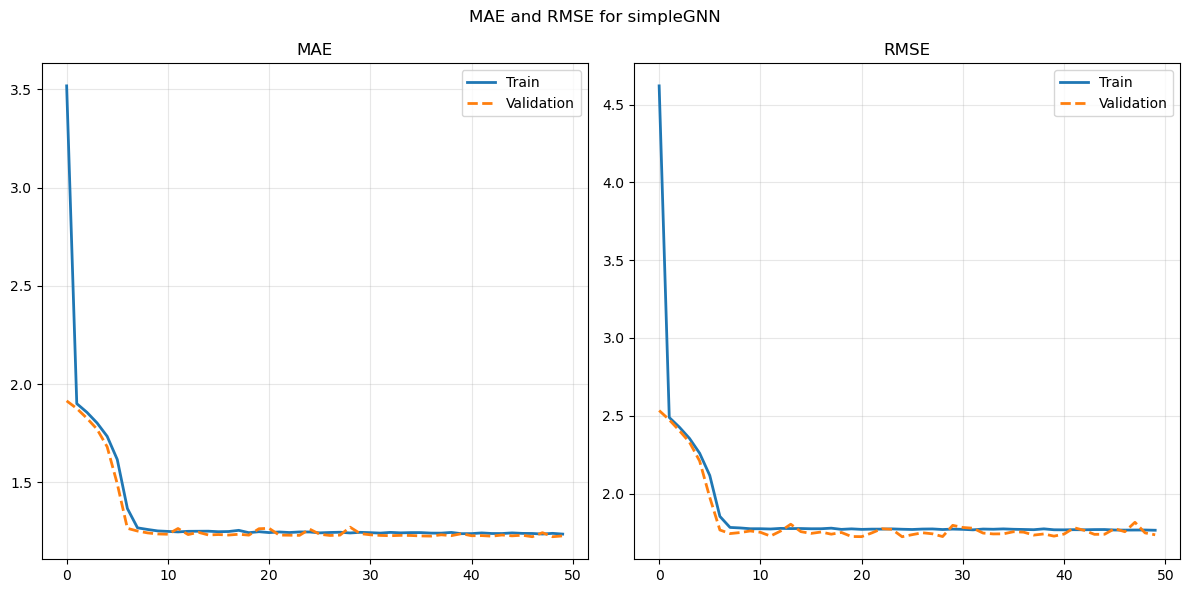

Train: Final MAE = 1.2367
Validation: Final MAE = 1.2275
Train: Final RMSE = 1.7644
Validation: Final RMSE = 1.7351


In [10]:
# preliminary results for simpleGNN

simpleGNN = SimpleGNN()

my_lr = 1e-4 # decreasing this val -> smoother loss curves 
my_loss_fn = nn.SmoothL1Loss() 
my_optimizer = optim.Adam(simpleGNN.parameters(), lr=my_lr) 

history = train_model(
    model = simpleGNN, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    loss_fn = my_loss_fn,
    optimizer = my_optimizer,
    epochs = 50,
    print_every = 10
)

plot_train_val(history, 'simpleGNN')

print(f"Train: Final MAE = {history['train_mae'][-1]:.4f}")
print(f"Validation: Final MAE = {history['val_mae'][-1]:.4f}")

print(f"Train: Final RMSE = {history['train_rmse'][-1]:.4f}")
print(f"Validation: Final RMSE = {history['val_rmse'][-1]:.4f}")

We did not explore this model further, as the literature suggests basic GCNs like this one struggle to capture complex quantum chemical relationships. However, it was an interesting thought experiment, and served as a good introduction to this type of neural network architecutre. 

###  Section 2.2: Adding Attention Pooling (GCNWithAttentionPooling)

Instead of aggregating node representations via global mean pooling, where all node features are averaged out (i.e., all equal importance), the below SimpleGNN variant, called GCNWithAttentionPooling, applies attention pooling. This allows the model to learn importance of each node/atom based on its features. This should allow GCNWithAttentionPooling to better learn realistic chemical relationships (i.e., functional groups), thereby improving model performance. 

We experimented with different attention pooling layers and channels. This architecture demonstrated the best performance, as measured by MAE and RMSE. 

In [43]:
# inherit from nn.Module 
class GCNWithAttentionPooling(nn.Module):
    def __init__(self):
        # call constructor from parent class 
        super().__init__()

        # define attention pooling -> map embedding/importance
        # increaseing num layers had biggest effect on accuracy 
        self.attention_pool = AttentionalAggregation(
            gate_nn=nn.Sequential(
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Linear(128, 128),
                nn.ReLU(),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Linear(64, 1)))

        self.attention = Sequential('x, edge_index, batch', [
            (GCNConv(1, 64), 'x, edge_index -> x'),
            nn.ReLU(),
            (GCNConv(64, 128), 'x, edge_index -> x'),
            nn.ReLU(),
            (GCNConv(128, 256), 'x, edge_index -> x'),
            nn.ReLU(),

            # POOLING: modified to attention pooling 
            (self.attention_pool, 'x, batch -> x'),

            # LINEAR LAYERS: turn into actual predictions 
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)])


    def forward(self, x, edge_index, batch):
        return self.attention(x, edge_index, batch).reshape(-1)

In [46]:
attention_poolingGCN = GCNWithAttentionPooling()

my_lr = 1e-4 # decreasing this val -> smoother loss curves; when lr = 1e-4, converges slowly slowly 
my_loss_fn = nn.SmoothL1Loss()
my_optimizer = optim.Adam(attention_poolingGCN.parameters(), lr=my_lr)

history = train_model(
    model = attention_poolingGCN, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    loss_fn = my_loss_fn,
    optimizer = my_optimizer,
    epochs = 20,
    print_every = 5
)

Training:  25%|██▌       | 5/20 [01:21<04:00, 16.04s/it]

Epoch   5/20 | Train Loss: 1.2225 | Val Loss: 1.1928


Training:  50%|█████     | 10/20 [02:43<02:42, 16.29s/it]

Epoch  10/20 | Train Loss: 0.8529 | Val Loss: 0.8614


Training:  75%|███████▌  | 15/20 [04:05<01:22, 16.43s/it]

Epoch  15/20 | Train Loss: 0.8405 | Val Loss: 0.8295


Training: 100%|██████████| 20/20 [05:28<00:00, 16.44s/it]

Epoch  20/20 | Train Loss: 0.8308 | Val Loss: 0.8255


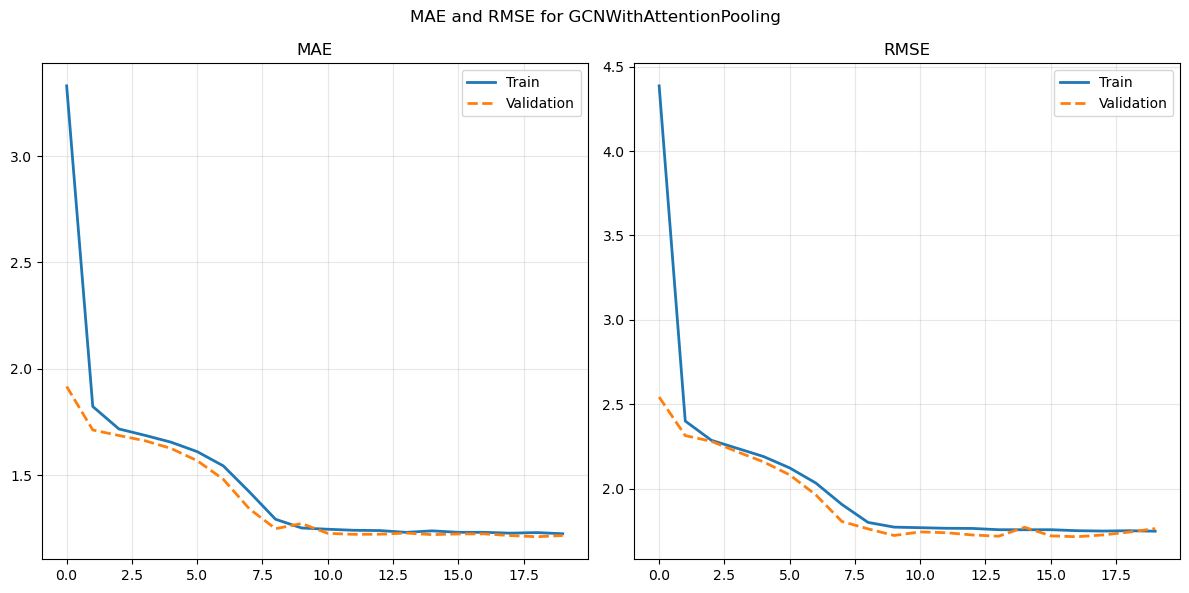

Train: Final MAE = 1.2257
Validation: Final MAE = 1.2174
Train: Final RMSE = 1.7474
Validation: Final RMSE = 1.7628


In [47]:
plot_train_val(history, 'GCNWithAttentionPooling')

print(f"Train: Final MAE = {history['train_mae'][-1]:.4f}")
print(f"Validation: Final MAE = {history['val_mae'][-1]:.4f}")

print(f"Train: Final RMSE = {history['train_rmse'][-1]:.4f}")
print(f"Validation: Final RMSE = {history['val_rmse'][-1]:.4f}")

In [48]:
attn_test_history = test_model(
    model=attention_poolingGCN,
    test_loader=test_loader,
    loss_fn=my_loss_fn,
    device='cpu')

print(attention_poolingGCN.parameters)
print(attn_test_history)

Test Loss: 0.7871 | Test MAE: 1.1783 | Test RMSE: 1.6660
<bound method Module.parameters of GCNWithAttentionPooling(
  (attention_pool): AttentionalAggregation(gate_nn=Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  ), nn=None)
  (attention): Sequential(
    (0) - GCNConv(1, 64): x, edge_index -> x
    (1) - ReLU(): x -> x
    (2) - GCNConv(64, 128): x, edge_index -> x
    (3) - ReLU(): x -> x
    (4) - GCNConv(128, 256): x, edge_index -> x
    (5) - ReLU(): x -> x
    (6) - AttentionalAggregation(gate_nn=Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
  